<a href="https://colab.research.google.com/github/Atharv-1905/Deep-Learning/blob/main/DL_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

--- Starting Part 1: MNIST with ANN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training ANN on MNIST...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9016 - loss: 0.3354 - val_accuracy: 0.9643 - val_loss: 0.1248
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9504 - loss: 0.1672 - val_accuracy: 0.9722 - val_loss: 0.0997
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9602 - loss: 0.1297 - val_accuracy: 0.9763 - val_loss: 0.0854
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9663 - loss: 0.1084 - val_accuracy: 0.9775 - val_loss: 0.0786
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9699 - loss: 0.0956 - val_accuracy: 0.9782 - val_loss: 0.0721
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (MNIST - ANN):
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.

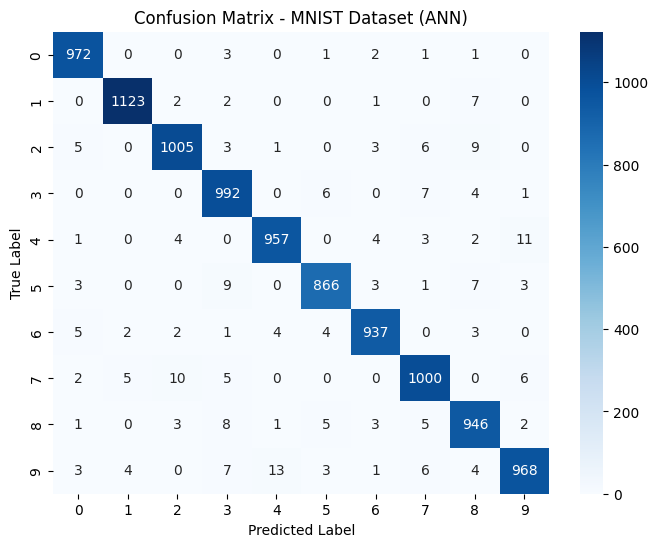

In [ ]:
print("--- Starting Part 1: MNIST with ANN ---")

# a) Perform Data Pre-processing (MNIST)
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = datasets.mnist.load_data()

# Scale pixel values to be between 0 and 1
X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

# b) Define Model and perform training (ANN)
ann_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("\nTraining ANN on MNIST...")
ann_model.fit(X_train_mnist, y_train_mnist, epochs=5, validation_split=0.1, batch_size=32, verbose=1)



In [ ]:
# c) Evaluate Results using confusion matrix (MNIST)
y_pred_ann = ann_model.predict(X_test_mnist)
y_pred_classes_ann = [np.argmax(element) for element in y_pred_ann]

print("\nClassification Report (MNIST - ANN):\n", classification_report(y_test_mnist, y_pred_classes_ann))

cm_ann = confusion_matrix(y_test_mnist, y_pred_classes_ann)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (MNIST - ANN):
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



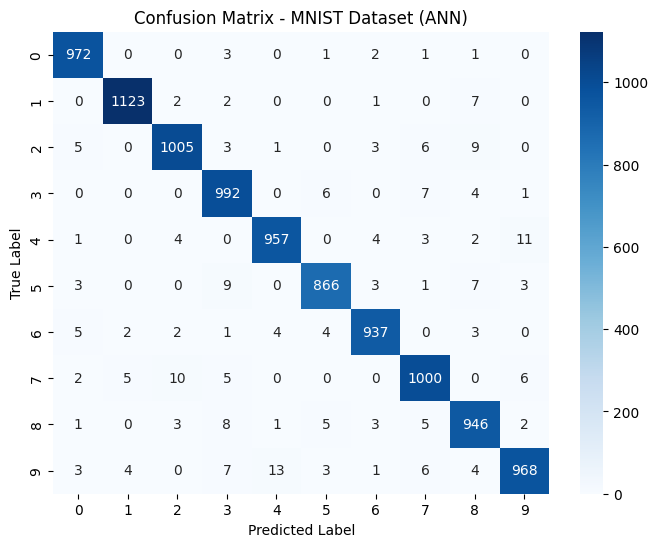

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST Dataset (ANN)')
plt.show()


--- Starting Part 2: CIFAR-10 with CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN on CIFAR-10...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 46ms/step - accuracy: 0.4496 - loss: 1.5280 - val_accuracy: 0.5628 - val_loss: 1.2585
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.5804 - loss: 1.1926 - val_accuracy: 0.6174 - val_loss: 1.0817
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.6252 - loss: 1.0720 - val_accuracy: 0.6440 - val_loss: 1.0229
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6523 - loss: 0.9992 - val_accuracy: 0.6560 - val_loss: 0.9946
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.6712 - loss: 0.9439 - val_accuracy: 0.6680 - val_loss: 0.9609
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 42ms/step - accuracy: 0.6854 - loss: 0.8956 - val_accuracy: 0.6872 - val_loss: 0.9036
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - accuracy: 0.6985 - loss: 0.8585 - val_accuracy: 0.6920 - val_loss: 0.9024
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 59s 4

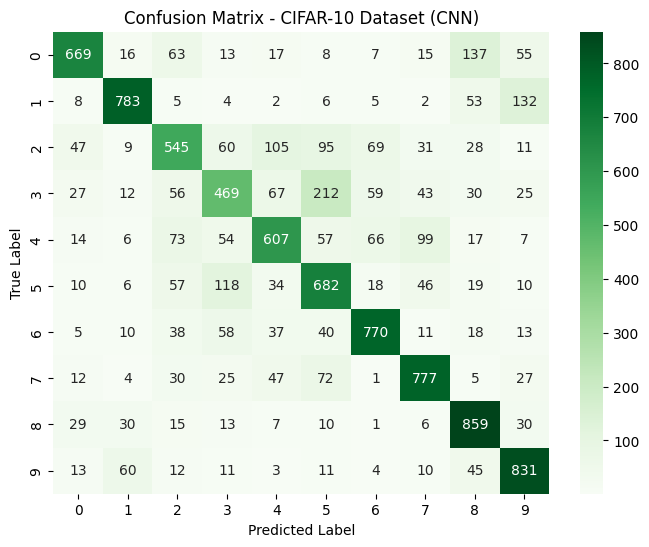

In [ ]:
print("\n--- Starting Part 2: CIFAR-10 with CNN ---")

# a) Perform Data Pre-processing (CIFAR-10)
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = datasets.cifar10.load_data()

# Scale pixel values to be between 0 and 1
X_train_cifar = X_train_cifar / 255.0
X_test_cifar = X_test_cifar / 255.0

# Flatten labels to a 1D array for easier matrix evaluation
y_train_cifar = y_train_cifar.flatten()
y_test_cifar = y_test_cifar.flatten()

# b) Define Model and perform training (CNN)
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("\nTraining CNN on CIFAR-10...")
cnn_model.fit(X_train_cifar, y_train_cifar, epochs=10, validation_split=0.1, batch_size=32, verbose=1)



In [ ]:
# c) Evaluate Results using confusion matrix (CIFAR-10)
y_pred_cifar = cnn_model.predict(X_test_cifar)
y_pred_classes_cifar = [np.argmax(element) for element in y_pred_cifar]

print("\nClassification Report (CIFAR-10 - CNN):\n", classification_report(y_test_cifar, y_pred_classes_cifar))

cm_cnn = confusion_matrix(y_test_cifar, y_pred_classes_cifar)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step

Classification Report (CIFAR-10 - CNN):
               precision    recall  f1-score   support

           0       0.80      0.67      0.73      1000
           1       0.84      0.78      0.81      1000
           2       0.61      0.55      0.58      1000
           3       0.57      0.47      0.51      1000
           4       0.66      0.61      0.63      1000
           5       0.57      0.68      0.62      1000
           6       0.77      0.77      0.77      1000
           7       0.75      0.78      0.76      1000
           8       0.71      0.86      0.78      1000
           9       0.73      0.83      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



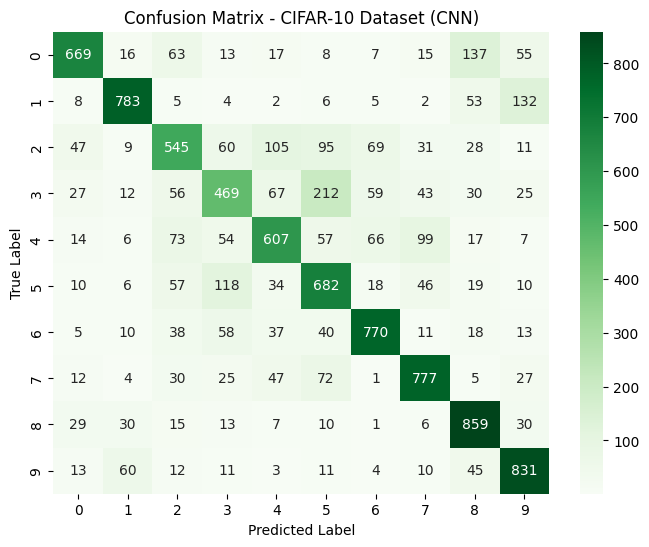

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CIFAR-10 Dataset (CNN)')
plt.show()